# Week 6 – Model Evaluation & Tuning

Objective:
- Evaluate model performance using multiple metrics
- Tune model parameters for better performance
- Validate model stability using cross-validation

In [15]:
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

In [16]:
COLUMNS = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
'wrong_fragment','urgent','hot','num_failed_logins','logged_in',
'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
'num_shells','num_access_files','num_outbound_cmds','is_host_login',
'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
'dst_host_same_srv_rate','dst_host_diff_srv_rate',
'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
'dst_host_serror_rate','dst_host_srv_serror_rate',
'dst_host_rerror_rate','dst_host_srv_rerror_rate','class','difficulty_level'
]

df = pd.read_csv("data/KDDTrain+.txt", names=COLUMNS)

df['binary_class'] = df['class'].apply(lambda x: 0 if x == 'normal' else 1)

X = df.drop(['class','binary_class','difficulty_level'], axis=1)
y = df['binary_class']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
preprocessor = joblib.load("models/preprocessor.pkl")

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [ ]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring='f1',  
    n_jobs=-1
)

grid.fit(X_train_processed, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

In [6]:
models = {
    "Random Forest (Tuned)": best_model,
    "Decision Tree": DecisionTreeClassifier(max_depth=15, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, random_state=42)
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)

    predictions[name] = y_pred

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

In [7]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest (Tuned),0.998889,0.999402,0.998209,0.998805
1,Decision Tree,0.998015,0.997783,0.997953,0.997868
2,Gradient Boosting,0.993570,0.994188,0.991984,0.993085


In [8]:
best_model_name = results_df.sort_values(by="F1 Score", ascending=False).iloc[0]['Model']

best_pred = predictions[best_model_name]

print("Best Model:", best_model_name)

Best Model: Random Forest (Tuned)


In [9]:
print("Classification Report:\n")
print(classification_report(y_test, best_pred))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13469
           1       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



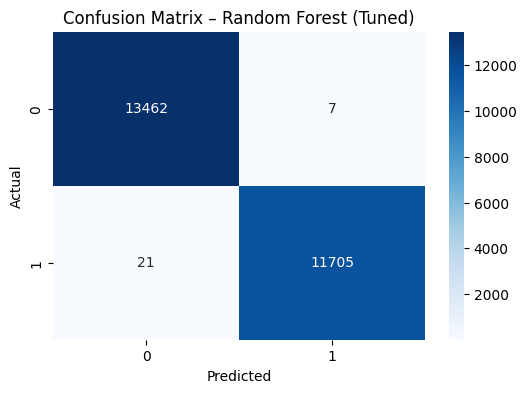

In [10]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title(f"Confusion Matrix – {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

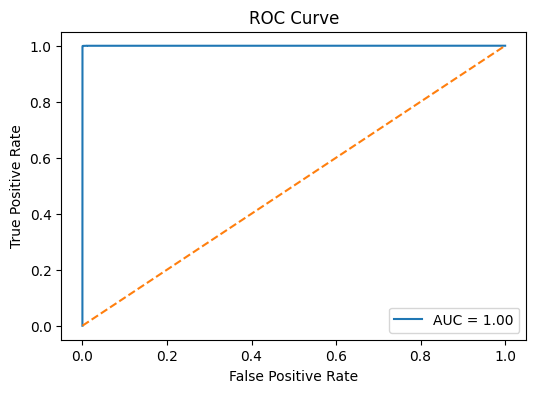

In [11]:
model = models[best_model_name]

# Only works for probabilistic models
if hasattr(model, "predict_proba"):
    y_probs = model.predict_proba(X_test_processed)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1], [0,1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")

    plt.legend()
    plt.show()

In [12]:
cv_scores = cross_val_score(
    best_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring='f1'
)

print("Cross-validation F1 scores:", cv_scores)
print("Mean F1 score:", cv_scores.mean())

Cross-validation F1 scores: [0.99813224 0.99791833 0.9981857  0.99877288 0.99823859]
Mean F1 score: 0.9982495474732088


In [13]:
print("Standard Deviation (Model Stability):", cv_scores.std())

Standard Deviation (Model Stability): 0.00028338388097097267


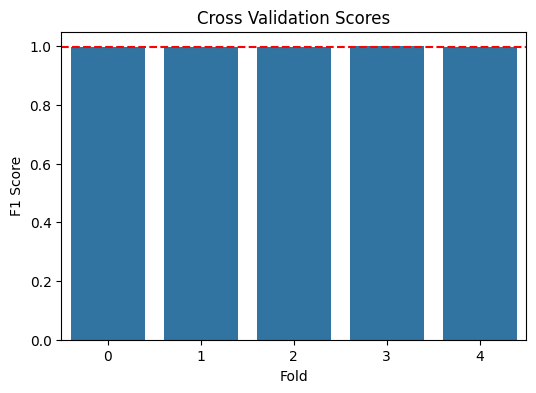

In [14]:
plt.figure(figsize=(6,4))
sns.barplot(x=list(range(len(cv_scores))), y=cv_scores)

plt.axhline(cv_scores.mean(), color='red', linestyle='--')

plt.title("Cross Validation Scores")
plt.xlabel("Fold")
plt.ylabel("F1 Score")

plt.show()

## Conclusion

- Multiple models were evaluated using key performance metrics.
- Random Forest with hyperparameter tuning achieved the best results.
- Recall remains critical in intrusion detection, as missing attacks is costly.
- Cross-validation confirmed that the model is stable and generalizes well.
- Overall, the system can effectively detect malicious network traffic.